<a href="https://colab.research.google.com/github/nyloanon/bachelor_thesis/blob/main/primitive_jax_flow_khi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Abstract
The goal of the following primitve/simple script is to train a generative model that generates synthetic KHI on a 64x64 grid. First the trainings/test data is generated with the hydrodynamic simulation methods provided by astronomix. Then the model is trained and later evaluated on a test set.       

## 1. Imports and simulation setup

In [45]:
!pip install astronomix -q
!pip install jax jaxlib flowjax optax equinox

In [46]:
# numerics
import jax
import jax.numpy as jnp
from jax.random import PRNGKey, uniform

# timing
from timeit import default_timer as timer

# plotting
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LogNorm
import matplotlib.animation as animation
from jaxtyping import Array, Float, Int

# astronomix
from astronomix import SimulationConfig
from astronomix import get_helper_data
from astronomix import SimulationParams
from astronomix import time_integration
from astronomix.option_classes.simulation_config import SnapshotSettings
from astronomix import construct_primitive_state
from astronomix import get_registered_variables
from astronomix.option_classes.simulation_config import finalize_config
from astronomix.option_classes.simulation_config import (
    BACKWARDS,
    DOUBLE_MINMOD,
    FORWARDS,
    HLL,
    HLLC,
    HYBRID_HLLC,
    MINMOD,
    OSHER,
    PERIODIC_BOUNDARY,
    BoundarySettings,
    BoundarySettings1D,
    FINITE_VOLUME,
    FINITE_DIFFERENCE
)

# model
import equinox as eqx

# training
import optax

In [47]:
print("👷 Setting up simulation...")

# simulation settings
gamma = 5/3

# spatial domain
box_size = 1.0
num_cells = 32

fixed_timestep = False
scale_time = False
dt_max = 0.1
num_timesteps = 2000

# setup simulation config
config = SimulationConfig(
    progress_bar = False,
    dimensionality = 2,
    box_size = box_size,
    num_cells = num_cells,
    fixed_timestep = fixed_timestep,
    differentiation_mode = FORWARDS,
    num_timesteps = num_timesteps,
    boundary_settings = BoundarySettings(
        x = BoundarySettings1D(PERIODIC_BOUNDARY, PERIODIC_BOUNDARY),
        y = BoundarySettings1D(PERIODIC_BOUNDARY, PERIODIC_BOUNDARY)
    ),
    limiter = DOUBLE_MINMOD,
    return_snapshots = False,
    riemann_solver = HYBRID_HLLC,
    solver_mode = FINITE_VOLUME
)

helper_data = get_helper_data(config)

params = SimulationParams(
    t_end = 2.0,
    C_cfl = 0.4
)

registered_variables = get_registered_variables(config)

👷 Setting up simulation...


In [48]:
def produce_plot(final_state, index):
  s = 0.1

  fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

  # equal aspect ratio
  ax1.set_aspect('equal', 'box')
  ax2.set_aspect('equal', 'box')
  ax3.set_aspect('equal', 'box')

  x = jnp.linspace(0, box_size, num_cells)
  y = jnp.linspace(0, box_size, num_cells)

  ym, xm = jnp.meshgrid(x, y)

  # on the first axis plot the density
  # log scaler
  norm_rho = LogNorm(vmin = jnp.min(final_state[0, :, :]), vmax = jnp.max(final_state[0, :, :]), clip = True)
  norm_p = LogNorm(vmin = jnp.min(final_state[3, :, :]), vmax = jnp.max(final_state[3, :, :]), clip = True)

  # ax1.scatter(xm.flatten(), ym.flatten(), c = final_state[0, :, :].flatten(), s = s, norm = norm_rho, marker = "s", cmap = "jet")
  # ax1.set_title("Density")

  ax1.imshow(final_state[0, :, :].T, norm = norm_rho, cmap = "jet", origin = "lower", extent = [0, box_size, 0, box_size])
  ax1.set_title("Density")

  # on the second axis plot the absolute velocity
  # abs_vel = jnp.sqrt(final_state[1, :, :]**2 + final_state[2, :, :]**2)

  # vel_norm = LogNorm(vmin = jnp.min(abs_vel), vmax = jnp.max(abs_vel), clip = True)

  ax2.imshow(final_state[1, :, :].T, cmap = "jet", origin = "lower", extent = [0, box_size, 0, box_size])
  ax2.set_title("Velocity")

  # on the third axis plot the pressure
  ax3.imshow(final_state[4, :, :].T, norm = norm_p, cmap = "jet", origin = "lower", extent = [0, box_size, 0, box_size])
  ax3.set_title("Pressure")

  plt.savefig(f"final_state_{index}.png")

## 2. KHI Init


In [49]:
def random_khi_fourier_modes(
    key,
    X,
    Y,
    amplitude=0.01,
    k_min=1,
    k_max=8,
    shear_layers=(0.25, 0.75),
    width=0.03,
    spectral_slope=1.0,
):
    """
    Random Fourier-mode perturbation for Kelvin-Helmholtz initialization.

    Produces a y-velocity perturbation of the form

        u_y(x, y) = A f(y) sum_k a_k sin(2 pi k x + phi_k)

    where f(y) localizes the perturbation around the shear layers.
    """

    modes = jnp.arange(k_min, k_max + 1)
    num_modes = modes.shape[0]

    key_amp, key_phase = jax.random.split(key)

    # random amplitudes with optional spectral decay
    coeffs = jax.random.normal(key_amp, (num_modes,))
    coeffs = coeffs / modes**spectral_slope

    # normalize so amplitude is controlled by `amplitude`
    coeffs = coeffs / jnp.sqrt(jnp.sum(coeffs**2) + 1e-30)

    phases = jax.random.uniform(
        key_phase,
        (num_modes,),
        minval=0.0,
        maxval=2.0 * jnp.pi,
    )

    # shape: (num_modes, nx, ny)
    fourier_sum = jnp.sum(
        coeffs[:, None, None]
        * jnp.sin(2.0 * jnp.pi * modes[:, None, None] * X[None, :, :] + phases[:, None, None]),
        axis=0,
    )

    # localize perturbation around both shear layers
    envelope = jnp.zeros_like(Y)
    for y0 in shear_layers:
        envelope = envelope + jnp.exp(-0.5 * ((Y - y0) / width) ** 2)

    return amplitude * envelope * fourier_sum

## 3. Primitive Flow implementation

### 3.1.1 MLP Model
Using Equinox library and Jax a velocity field on a 64x64 grid is set up.

In [50]:
class Velocity_field_mlp(eqx.Module):

  mlp: eqx.nn.MLP

  def __init__(self, key, dim):

    self.mlp = eqx.nn.MLP(
        in_size = dim + 1, # x + t
        out_size = dim, # v
        width_size = 128,
        depth = 3,
        key = key
    )

  def __call__(self, x, t):

    x_flat = x.reshape(-1)
    t = jnp.array([t])
    x_t = jnp.concatenate([x_flat, t])
    v = self.mlp(x_t)

    return v.reshape(x.shape)

### 3.1.2 CNN Model
Using the Equinox library and Jax a CNN velocity field on a 64x64 grid is set up. The activation function used in all hidden layers is the SiLu function: $\text{SiLu}(x) = x \cdot \sigma(x)$.

In [59]:
class Velocity_field_cnn(eqx.Module):
  conv1: eqx.nn.Conv2d
  conv2: eqx.nn.Conv2d
  conv3: eqx.nn.Conv2d
  conv4: eqx.nn.Conv2d
  conv5: eqx.nn.Conv2d

  def __init__(self, key):

    keys = jax.random.split(key, 5)   # number of keys matches number of layers

    self.conv1 = eqx.nn.Conv2d(
        1, 32, kernel_size=3, padding=1, key=keys[0]
    )
    self.conv2 = eqx.nn.Conv2d(
        32, 64, kernel_size=3, padding=1, key=keys[1]
    )
    self.conv3 = eqx.nn.Conv2d(
        64, 64, kernel_size=3, padding=1, key=keys[2]
    )
    self.conv4 = eqx.nn.Conv2d(
        64, 32, kernel_size=3, padding=1, key=keys[3]
    )
    self.conv5 = eqx.nn.Conv2d(
        32, 1, kernel_size=3, padding=1, key=keys[4]
    )

  def __call__(self, x, t):
    # shape of x (1, 64, 64)
    x = x + t

    h = jax.nn.silu(self.conv1(x))
    h = jax.nn.silu(self.conv2(h))
    h = jax.nn.silu(self.conv3(h))
    h = jax.nn.silu(self.conv4(h))

    v = self.conv5(h)

    return v

### 3.2 Data generation
Data pairs are sampled and the current point at time $t$, the time $t$ itself and the target velocity $v_\text{target}$ are returned.

In [52]:
def sample_pair(key, data):

  key1, key2, key3 = jax.random.split(key, 3)
  idx = jax.random.normal(key1, (), 0, len(data))

  x1 = data[idx] # real data
  x0 = jax.random.normal(key2, shape = x0.shape) # noise

  t = jax.random.uniform(key3, (1,))

  x_t = (1-t) * x0 + t * x1
  v_target = x1 - x0

  return x_t, t, v_target

### 3.3 Loss function
For the loss a simple mean squared error is implemented.

In [53]:
def loss_function(model, x_t, t, v_target, modelname):

  # adjust size for CNN

  if modelname == 0:
    v_prediction = model(x_t, t)
  elif modelname == 1:
    x_t = x_t[None, :, :] # expand dimension
    x_t = x_t + t
    v_prediction = model(x_t, t)
    v_prediction = v_prediction[0]

  return jnp.mean((v_target - v_prediction) ** 2)


### 3.4 Training
Using the optax library we set up the training of the model.

In [54]:
optimizer = optax.adam(1e-4)

@eqx.filter_jit
def train_step(model, optimal_state, x_t, t, v_target, modelname):

  loss, grads = eqx.filter_value_and_grad(loss_function)(model, x_t, t, v_target, modelname)

  updates, opt_state = optimizer.update(grads, optimal_state)

  model = eqx.apply_updates(model, updates)

  return model, opt_state, loss

### 3.5 Sampling

In [55]:
def sample(model, x, steps, modelname):

    dt = 1.0 / steps

    if modelname == 1:
      x = x[None, :, :]   # add channel for CNN

    for i in range(steps):

      t = i / steps

      v = model(x, t)   # <-- v_theta(x_t)

      x = x + dt * v

    if modelname == 1:
      return x[0]

    return x



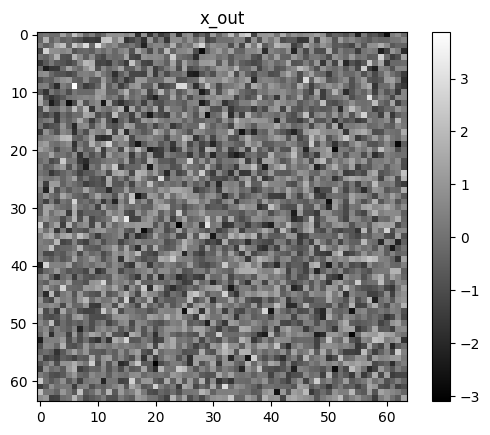

In [60]:
key = jax.random.key(1)
x = jax.random.normal(key, shape = (64,64))
x_flat = x.reshape(-1)
model = Velocity_field_cnn(key)
x_out = sample(model, x, steps = 100, modelname=1)
plt.imshow(x_out, cmap="gray")
plt.colorbar()
plt.title("x_out")
plt.show()
